# Análisis de sentimiento (BERT) y modelado temático (LDA)

**Donación de sangre en redes sociales**

Este notebook aplica:
1. **LDA (Latent Dirichlet Allocation)** sobre el corpus unificado para descubrir temas recurrentes y clasificar barreras (psicológicas, cognitivas, contextuales).
2. **Análisis de sentimiento con BERT** (modelo en español) sobre el mismo corpus.

Los modelos se ajustan sobre **todo el corpus**; los resultados se presentan **por RRSS y global** para comparar plataformas y obtener una visión agregada.

**Requisitos:**  
`pip install --user -r requirements_analisis.txt`  
(Si sale *Acceso denegado* al instalar sin `--user`, usa la opción `--user` para instalar en tu carpeta de usuario.)  
Luego ejecuta **una vez** la celda de `nltk.download("stopwords")` que está justo debajo de "Configuración y carga de datos".

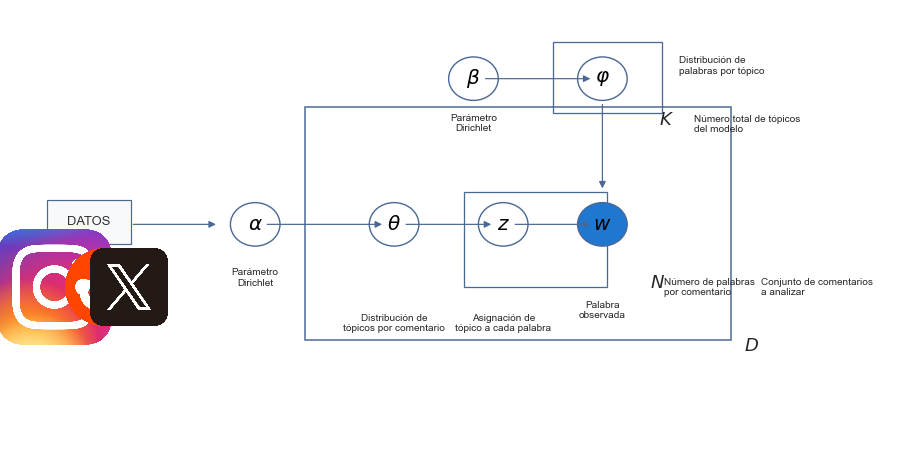

In [97]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

# -----------------------------
# CONFIGURACIÓN GENERAL
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 18)
ax.set_ylim(0, 10)
ax.axis("off")

edge_color = "#4a6896"
fill_light = "#f8f9fb"
fill_dark = "#1f77d0"

# Ruta de los logos
ruta_logos = "Gráficos/logos/"

# -----------------------------
# FUNCIÓN PARA AÑADIR LOGOS
# -----------------------------
def add_logo(ax, filepath, xy, zoom=0.10):
    if os.path.exists(filepath):
        img = mpimg.imread(filepath)
        imagebox = OffsetImage(img, zoom=zoom)
        ab = AnnotationBbox(imagebox, xy, frameon=False)
        ax.add_artist(ab)
    else:
        print(f"No se encontró: {filepath}")

# -----------------------------
# RECTÁNGULOS PRINCIPALES
# -----------------------------
# Caja de datos
data_box = Rectangle((0.8, 4.55), 1.7, 1.0, facecolor=fill_light, edgecolor=edge_color, linewidth=1.2)
ax.add_patch(data_box)
ax.text(1.65, 5.05, "DATOS", ha="center", va="center", fontsize=13, color="#333333")

# Rectángulo exterior (D)
outer = Rectangle((6.0, 2.35), 8.6, 5.35, fill=False, linewidth=1.5, edgecolor=edge_color)
ax.add_patch(outer)

# Rectángulo interior (N)
inner = Rectangle((9.2, 3.55), 2.9, 2.2, fill=False, linewidth=1.3, edgecolor=edge_color)
ax.add_patch(inner)

# Caja de phi
phi_box = Rectangle((11.0, 7.55), 2.2, 1.65, fill=False, linewidth=1.3, edgecolor=edge_color)
ax.add_patch(phi_box)

# -----------------------------
# NODOS
# -----------------------------
coords = {
    "alpha": (5.0, 5.0),
    "theta": (7.8, 5.0),
    "z": (10.0, 5.0),
    "w": (12.0, 5.0),
    "beta": (9.4, 8.35),
    "phi": (12.0, 8.35),
}

labels = {
    "alpha": r"$\alpha$",
    "theta": r"$\theta$",
    "z": r"$z$",
    "w": r"$w$",
    "beta": r"$\beta$",
    "phi": r"$\varphi$",
}

for name, (x, y) in coords.items():
    fc = fill_dark if name == "w" else "white"
    tc = "black" if name != "w" else "black"
    circ = Circle((x, y), 0.50, facecolor=fc, edgecolor=edge_color, linewidth=1.4)
    ax.add_patch(circ)
    ax.text(x, y, labels[name], ha="center", va="center", fontsize=20, color=tc)

# -----------------------------
# FLECHAS
# -----------------------------
def arrow(p1, p2, shrinkA=12, shrinkB=12):
    ax.add_patch(
        FancyArrowPatch(
            p1, p2,
            arrowstyle="-|>",
            mutation_scale=14,
            linewidth=1.2,
            color=edge_color,
            shrinkA=shrinkA,
            shrinkB=shrinkB
        )
    )

# Flechas principales
arrow((2.5, 5.0), (4.45, 5.0), shrinkA=2, shrinkB=12)
arrow(coords["alpha"], coords["theta"])
arrow(coords["theta"], coords["z"])
arrow(coords["z"], coords["w"])
arrow(coords["beta"], coords["phi"])
arrow((12.0, 7.85), (12.0, 5.55), shrinkA=4, shrinkB=12)

# -----------------------------
# ETIQUETAS EXPLICATIVAS
# -----------------------------
# alpha
ax.text(5.0, 4.00, "Parámetro\nDirichlet", ha="center", va="top", fontsize=10)

# theta
ax.text(7.8, 2.95, "Distribución de\ntópicos por comentario", ha="center", va="top", fontsize=10)

# z
ax.text(10.0, 2.95, "Asignación de\ntópico a cada palabra", ha="center", va="top", fontsize=10)

# w
ax.text(12.0, 3.25, "Palabra\nobservada", ha="center", va="top", fontsize=10)

# beta
ax.text(9.4, 7.55, "Parámetro\nDirichlet", ha="center", va="top", fontsize=10)

# phi
ax.text(13.55, 8.65, "Distribución de\npalabras por tópico", ha="left", va="center", fontsize=10)

# K, N, D
ax.text(13.15, 7.30, r"$K$", fontsize=18)
ax.text(13.85, 7.30, "Número total de tópicos\ndel modelo", ha="left", va="center", fontsize=10)

ax.text(12.95, 3.55, r"$N$", fontsize=18)
ax.text(13.25, 3.55, "Número de palabras\npor comentario", ha="left", va="center", fontsize=10)

ax.text(14.85, 2.10, r"$D$", fontsize=18)
ax.text(15.20, 3.55, "Conjunto de comentarios\na analizar", ha="left", va="center", fontsize=10)

# -----------------------------
# LOGOS EN LA ZONA DE DATOS
# -----------------------------
# texto pequeño debajo de DATOS
ax.text(1.65, 4.05, "Instagram · TikTok\nReddit · X", ha="center", va="top", fontsize=9, color=edge_color)

# posiciones de logos
add_logo(ax, os.path.join(ruta_logos, "instagram.png"), (0.95, 3.55), zoom=0.09)
add_logo(ax, os.path.join(ruta_logos, "tiktok.png"),    (1.45, 3.55), zoom=0.09)
add_logo(ax, os.path.join(ruta_logos, "reddit.png"),    (1.95, 3.55), zoom=0.09)
add_logo(ax, os.path.join(ruta_logos, "x.png"),         (2.45, 3.55), zoom=0.09)

# Guardar
plt.savefig("diagrama_lda_tfg_mejorado.png", dpi=300, bbox_inches="tight")
plt.savefig("diagrama_lda_tfg_mejorado.svg", bbox_inches="tight")
plt.show()

## 1. Configuración y carga de datos

**Si sale `ModuleNotFoundError: No module named 'gensim'`:** ejecuta la celda de abajo que dice `%pip install --user gensim ...` (usa el mismo Python que el notebook). Después **reinicia el kernel** (Kernel → Restart) y vuelve a ejecutar desde el inicio.\n\n**Antes de ejecutar:** Si es la primera vez, ejecuta también la celda de `nltk.download(\"stopwords\")`. Solo hace falta una vez.

In [ ]:
# Si sale ModuleNotFoundError (gensim, nltk, etc.), ejecuta esta celda UNA VEZ.
# Instala en el mismo Python que usa este notebook.
%pip install --user gensim nltk matplotlib seaborn transformers torch

In [ ]:
# Ejecutar UNA VEZ para descargar stopwords (NLTK). Si ya lo hiciste, puedes saltar esta celda.
import nltk
nltk.download("stopwords", quiet=False)

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_style("white")
BASE = Path(".").resolve()

In [2]:
# Cargar corpus unificado (salida del notebook de limpieza)
path_union = BASE / "datos_procesados_union_todas_fuentes.csv"
df = pd.read_csv(path_union)
# Usar texto limpio (sin emojis) para LDA y BERT
df["texto_analisis"] = df["text_clean"].fillna(df["text"]).astype(str).str.strip()
df = df[df["texto_analisis"].str.len() >= 3].copy()
df = df.reset_index(drop=True)
print("Filas:", len(df))
print(df["fuente"].value_counts())
df.dtypes

Filas: 3079
fuente
instagram    1233
tiktok        684
reddit        605
twitter       557
Name: count, dtype: int64


fuente            object
text              object
text_clean        object
emojis            object
fecha             object
likes              int64
respuestas         int64
texto_analisis    object
dtype: object

### Traducción al español (opcional)

Para que LDA y el modelo de sentimiento en español trabajen mejor, se pueden detectar comentarios en otros idiomas y traducirlos al español. Si no quieres traducir, **salta esta celda** y deja `texto_analisis` como está.

**Requisito:** `pip install langdetect deep-translator` (o ejecuta la celda de instalación de abajo).

In [3]:
# Opcional: traducir a español los textos que no estén en español
# Si no quieres usar traducción, comenta TODO el bloque "Traducción" (hasta el print final) y ejecuta solo:
# df["idioma_detectado"] = "es"

import time
try:
    from langdetect import detect, LangDetectException
except ImportError:
    %pip install --user langdetect
    from langdetect import detect, LangDetectException
try:
    from deep_translator import GoogleTranslator
except ImportError:
    %pip install --user deep-translator
    from deep_translator import GoogleTranslator

def detectar_idioma(texto):
    try:
        if pd.isna(texto) or len(str(texto).strip()) < 10:
            return "es"
        return detect(str(texto)[:500])
    except (LangDetectException, Exception):
        return "es"

def traducir_a_es(texto):
    try:
        if pd.isna(texto) or not str(texto).strip():
            return str(texto)
        t = str(texto).strip()[:4500]
        return GoogleTranslator(source="auto", target="es").translate(t) or texto
    except Exception:
        return texto

# Detectar idioma (puede tardar un poco)
print("Detectando idioma...")
df["idioma_detectado"] = df["texto_analisis"].apply(detectar_idioma)
conteo_idiomas = df["idioma_detectado"].value_counts()
print(conteo_idiomas.head(10))

# Traducir solo los que no sean español
no_es = df["idioma_detectado"] != "es"
n_traducir = no_es.sum()
MAX_A_TRADUCIR = None  # ej. 100 para probar solo unos cuantos; None = todos
indices_no_es = df.index[no_es]
if MAX_A_TRADUCIR is not None and n_traducir > MAX_A_TRADUCIR:
    indices_no_es = indices_no_es[:MAX_A_TRADUCIR]
    n_traducir = len(indices_no_es)
if n_traducir > 0:
    print(f"Traduciendo {n_traducir} textos al español (pausa 0.3 s entre cada uno)...")
    for idx in indices_no_es:
        df.at[idx, "texto_analisis"] = traducir_a_es(df.at[idx, "texto_analisis"])
        time.sleep(0.3)
    print("Hecho.")
else:
    print("Todos los textos están en español (o se asumió español).")

Detectando idioma...
idioma_detectado
es    2725
pt      74
en      39
ca      36
sl      34
it      28
tl      21
et      12
fr      10
so       9
Name: count, dtype: int64
Traduciendo 354 textos al español (pausa 0.3 s entre cada uno)...
Hecho.


## 1.1 Visualizaciones exploratorias

Solo: **frecuencia por idioma** (ejecuta antes la celda de traducción), **línea temporal** de comentarios por fecha y **emoticonos** más usados. Sin rejilla de fondo.

*(Wordcloud y TF-IDF unigramas/bigramas/trigramas están en la sección 4.1, después de BERT.)*

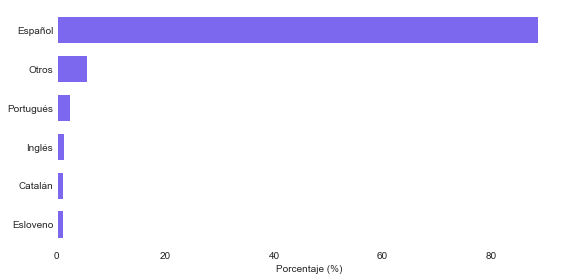

In [4]:
# Frecuencia relativa por idioma (ejecuta antes la celda de traducción para idioma_detectado)
NOMBRES_IDIOMAS = {
    "es": "Español", "pt": "Portugués", "en": "Inglés", "sl": "Esloveno", "ca": "Catalán",
    "it": "Italiano", "tl": "Tagalo", "et": "Estonio", "de": "Alemán", "fr": "Francés",
    "fi": "Finlandés", "af": "Afrikáans", "nl": "Holandés", "vi": "Vietnamita", "no": "Noruego",
    "ro": "Rumano", "hu": "Húngaro", "pl": "Polaco", "sv": "Sueco", "sk": "Eslovaco", "da": "Danés", "cs": "Checo",
    "so": "Somalí", "sw": "Suajili", "cy": "Galés", "lv": "Letón", "hr": "Croata", "id": "Indonesio", "sq": "Albanés",
}
if "idioma_detectado" in df.columns:
    idioma_pct = (df["idioma_detectado"].value_counts(normalize=True) * 100)
    idioma_pct = idioma_pct[idioma_pct > 0]
    orden = idioma_pct.sort_values(ascending=False)
    if "it" in orden.index:
        idx = orden.index.tolist().index("it")
        principales = orden.iloc[:idx]
        otros_val = orden.iloc[idx:].sum()
    else:
        principales = orden
        otros_val = 0
    principales = principales.rename(index=lambda c: NOMBRES_IDIOMAS.get(c, c))
    if otros_val > 0:
        principales = pd.concat([principales, pd.Series({"Otros": otros_val})])
    principales = principales.sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(4, len(principales) * 0.4)))
    principales.plot(kind="barh", ax=ax, color="#7b68ee", width=0.7)
    ax.set_xlabel("Porcentaje (%)")
    ## ax.set_title("Frecuencia relativa por idioma identificado")
    ax.grid(False)
    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="both", which="both", length=0)
    plt.tight_layout()
    plt.show()
else:
    print("No hay columna idioma_detectado. Ejecuta la celda de traducción para generarla.")

<ipython-input-5-b05ffefa6af5>:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


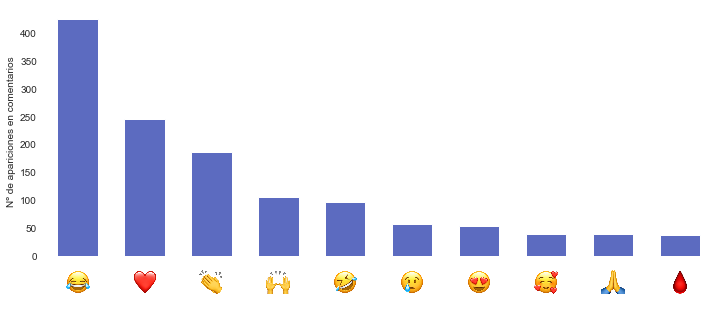

Tabla de referencia:


,#,Emoji,Código Unicode,Nº comentarios
0,1,😂,U+1F602,426
1,2,❤️,U+2764 U+FE0F,245
2,3,👏,U+1F44F,187
3,4,🙌,U+1F64C,105
4,5,🤣,U+1F923,96
5,6,😢,U+1F622,58
6,7,😍,U+1F60D,53
7,8,🥰,U+1F970,40
8,9,🙏,U+1F64F,39
9,10,🩸,U+1FA78,38


In [5]:
# Emoticonos/emojis más utilizados: gráfico de barras + tabla de referencia debajo
# Cada racha de emojis iguales seguidos cuenta como 1 (ej: 😂😂😂 en un comentario = 1 vez 😂)
from collections import Counter

def lista_emojis_por_comentario(texto):
    """Extrae emojis en orden; si hay librería emoji, segmenta bien (😂😂😂 -> [😂,😂,😂])."""
    s = (texto or "").strip()
    if not s:
        return []
    try:
        import emoji
        # emoji_list devuelve posiciones; extraemos el substring de cada emoji
        lst = emoji.emoji_list(s)
        return [s[m["match_start"]:m["match_end"]] for m in lst]
    except Exception:
        return s.split()

def colapsar_consecutivos(tokens):
    """De [😂, 😂, 😂, ❤️, ❤️] pasa a [😂, ❤️]: cada racha cuenta como uno."""
    if not tokens:
        return []
    out = [tokens[0]]
    for t in tokens[1:]:
        if t != out[-1]:
            out.append(t)
    return out

emoji_flat = []
for s in df["emojis"].dropna().astype(str):
    tokens = lista_emojis_por_comentario(s)
    emoji_flat.extend(colapsar_consecutivos(tokens))
cnt = Counter(emoji_flat)
top_emoji = cnt.most_common(10)

def emoji_a_codigo(emoji_str):
    """Código Unicode del emoji (ej: U+2764 U+FE0F) para identificar si no se ve el glifo."""
    return " ".join(f"U+{ord(c):04X}" for c in emoji_str)

if top_emoji:
    import matplotlib.image as mpimg
    from matplotlib.offsetbox import OffsetImage, AnnotationBbox
    from matplotlib.gridspec import GridSpec

    fig = plt.figure(figsize=(12, 5.5))
    gs = GridSpec(2, 1, height_ratios=[1.8, 0.35], hspace=0.01)
    ax_bars = fig.add_subplot(gs[0])
    ax_emojis = fig.add_subplot(gs[1])

    spacing = 1.0
    n = len(top_emoji)
    x = np.arange(n) * spacing
    vals = [e[1] for e in top_emoji]
    ax_bars.bar(x, vals, color="#5c6bc0", width=0.6)
    ax_bars.set_xticks(x)
    ax_bars.set_xticklabels([])

    # sin eje X ni eje Y (ni líneas ni marcas)
    ax_bars.spines["top"].set_visible(False)
    ax_bars.spines["right"].set_visible(False)
    ax_bars.spines["bottom"].set_visible(False)
    ax_bars.spines["left"].set_visible(False)
    ax_bars.tick_params(bottom=False, left=False)

    ax_bars.set_ylabel("Nº de apariciones en comentarios")
    ## ax_bars.set_title("Emoticonos más utilizados en los comentarios", fontsize=11)
    ax_bars.set_xlim(-0.5 * spacing, (n - 1) * spacing + 0.5 * spacing)

    # Eje X = franja con los emojis (como etiquetas del eje)
    ax_emojis.set_xlim(-0.5 * spacing, (n - 1) * spacing + 0.5 * spacing)
    ax_emojis.set_ylim(0, 1)
    ax_emojis.set_axis_off()
    ax_emojis.patch.set_visible(False)
    emojis_dir = BASE / "emojis"
    for i in range(min(10, len(top_emoji))):
        path_img = emojis_dir / f"emoji{i + 1}.png"
        if path_img.exists():
            img = mpimg.imread(str(path_img))
            im = OffsetImage(img, zoom=0.15)
            ab = AnnotationBbox(im, (i * spacing, 0.5), xycoords="data", frameon=False, boxcoords="data", pad=0)
            ax_emojis.add_artist(ab)
    plt.tight_layout()
    plt.show()

    # Tabla de referencia: posición en el gráfico (barra 1 = primera fila), emoji, código Unicode y cuenta
    tabla_emoji = pd.DataFrame([
        {"#": i + 1, "Emoji": e[0], "Código Unicode": emoji_a_codigo(e[0]), "Nº comentarios": e[1]}
        for i, e in enumerate(top_emoji)
    ])
    print("Tabla de referencia:")
    display(tabla_emoji)
else:
    print("No hay emojis en la columna emojis.")

## 2. Preprocesamiento para LDA

Tokenización, eliminación de stopwords en español y construcción del diccionario y corpus.

In [3]:
import re
import pandas as pd
import nltk
import spacy

try:
    nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
except:
    !python -m spacy download es_core_news_sm
    nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])

In [4]:
import spacy
nlp = spacy.load("es_core_news_sm")
print("Modelo cargado correctamente")

Modelo cargado correctamente


In [5]:
try:
    from nltk.corpus import stopwords
except:
    nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords

STOP = set(stopwords.words("spanish"))

STOP |= {
    "q", "qe", "k", "x", "d", "t", "tb", "tmb", 
    "si", "sí", "no", "ya", "mas", "más", "pero", 
    "porque", "como", "que", "los", "las", "una", "uno", 
    "del", "al", "en", "es", "se", "le", "lo", 
    "da", "donar", "donación", "sangre", "así", 
    "solo", "tan", "pues", "creo", "hace", "cada", 
    "tipo", "forma", "luego", "algún", "tener", 
    "tiene", "tienen", "jajaja", "jaja", "españa", 
    "madrid", "escrito", "persona", "personas", "cosas", 
    "algo", "nada", "nuevo", "nueva", "primeros", "hola",
    "comunidad", "vaya", "comentario", "comentarios", "video", "saludo", "saludos",
    "gente", "mucha", "mucho", "gracia", "gracias", "mensaje", "amigo",
    "jess", "caso", "cosa", "donante", "momento", "jessi", "segun",
    "año", "día","mes" "primero", "bueno", "verdad", "campaña","tema"
}

# inglés por si se cuela algo
STOP |= {
    "the", "and", "is", "are", "was", "were", "have", "has", "had",
    "can", "could", "would", "should", "this", "that", "with", "for",
    "from", "your", "you", "they", "them", "their", "what", "when",
    "where", "which", "who", "how", "all", "any", "not", "just",
    "out", "about"
}

In [6]:
PATRON_URL = re.compile(r"https?://\S+|www\.\S+|\S+\.com\S*|t\.co/\S+", re.IGNORECASE)

def limpiar_texto_base(texto):
    if pd.isna(texto) or not isinstance(texto, str):
        return ""
    t = str(texto).lower().strip()
    t = PATRON_URL.sub(" ", t)
    t = re.sub(r"[@#]\w+", " ", t)              # menciones y hashtags
    t = re.sub(r"[^a-záéíóúñü\s]", " ", t)      # solo letras
    t = re.sub(r"\s+", " ", t).strip()
    return t

In [7]:
textos_limpios = df["texto_analisis"].fillna("").astype(str).map(limpiar_texto_base).tolist()

tokens_docs = []

for doc in nlp.pipe(textos_limpios, batch_size=100):
    tokens = []
    for tok in doc:
        lema = tok.lemma_.lower().strip()

        if (
            tok.is_alpha
            and len(lema) > 2
            and lema not in STOP
            and tok.pos_ in {"NOUN", "ADJ", "PROPN"}
        ):
            tokens.append(lema)

    tokens_docs.append(tokens)

df["tokens"] = tokens_docs
df["n_tokens"] = df["tokens"].str.len()
df = df[df["n_tokens"] >= 2].copy().reset_index(drop=True)

print("Documentos con al menos 2 tokens útiles:", len(df))

Documentos con al menos 2 tokens útiles: 1827


In [8]:
ej = "Tengo miedo a las agujas y no puedo donar. Doné ayer en Madrid."
doc = nlp(ej)
[(t.text, t.lemma_, t.pos_) for t in doc if t.is_alpha]

[('Tengo', 'tener', 'VERB'),
 ('miedo', 'miedo', 'NOUN'),
 ('a', 'a', 'ADP'),
 ('las', 'el', 'DET'),
 ('agujas', 'aguja', 'NOUN'),
 ('y', 'y', 'CCONJ'),
 ('no', 'no', 'ADV'),
 ('puedo', 'poder', 'AUX'),
 ('donar', 'donar', 'VERB'),
 ('Doné', 'Doné', 'PROPN'),
 ('ayer', 'ayer', 'ADV'),
 ('en', 'en', 'ADP'),
 ('Madrid', 'Madrid', 'PROPN')]

In [9]:
for i in range(5):
    print("Texto original:", df.loc[i, "texto_analisis"])
    print("Tokens:", df.loc[i, "tokens"])
    print("-" * 80)

Texto original: Excelente video!! Fuerzas Jessi, comparto
Tokens: ['excelente', 'fuerza', 'comparto']
--------------------------------------------------------------------------------
Texto original: Bendiciones familia!!!! Vamos Segun!!!
Tokens: ['bendición', 'familio']
--------------------------------------------------------------------------------
Texto original: Compartido!!!! Vamos Segu
Tokens: ['compartido', 'segu']
--------------------------------------------------------------------------------
Texto original: Un abrazo fuerte!
Tokens: ['abrazo', 'fuerte']
--------------------------------------------------------------------------------
Texto original: Ya soy donante de médula desde el 2015!! Que lindo sería poder ser de ayuda para todos los niños y personas que lo necesitan!!
Tokens: ['médula', 'ayuda', 'niño']
--------------------------------------------------------------------------------


In [10]:
from gensim.models import Phrases
from gensim.models.phrases import Phraser

lista_tokens = df["tokens"].tolist()

bigram = Phrases(lista_tokens, min_count=5, threshold=10)
bigram_mod = Phraser(bigram)

lista_tokens_bigram = [bigram_mod[doc] for doc in lista_tokens]

df["tokens_lda"] = lista_tokens_bigram

In [11]:
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
dictionary = corpora.Dictionary(df["tokens_lda"])

dictionary.filter_extremes(
    no_below=5,
    no_above=0.25,
    keep_n=5000
)

corpus = [dictionary.doc2bow(t) for t in df["tokens_lda"]]

print("Tamaño del diccionario:", len(dictionary))
print("Documentos en corpus:", len(corpus))

Tamaño del diccionario: 456
Documentos en corpus: 1827


*(La **traducción al español** (opcional) está en las celdas justo después de «Cargar corpus». Ejecuta aquellas si quieres usar `idioma_detectado` y la visualización por idioma en la sección 1.1.)*

In [ ]:
# La traducción está en las celdas justo después de «Cargar corpus». Ejecuta aquellas si quieres idioma_detectado.
pass

## 3. LDA: selección del número de temas y modelo final

**Alternativa:** Si prefieres no ejecutar la búsqueda de coherencia (tarda unos minutos), fija el número de temas y salta a la celda del modelo final. Por ejemplo: `n_topics = 6` o `n_topics = 8`.

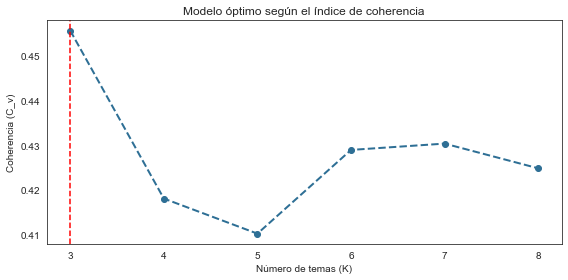

K sugerido por coherencia: 3


In [77]:
import numpy as np
import matplotlib.pyplot as plt

coherencias = []
K_list = list(range(3, 9))

for k in K_list:
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=20,
        alpha="auto",
        per_word_topics=True
    )

    cm = CoherenceModel(
        model=model,
        texts=df["tokens_lda"].tolist(),
        dictionary=dictionary,
        coherence="c_v"
    )

    coherencias.append(cm.get_coherence())

k_optimo = K_list[np.argmax(coherencias)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_list, coherencias, linestyle="--", marker="o", color="#2e6f95", linewidth=2)
ax.axvline(k_optimo, linestyle="--", color="red", linewidth=1.5)
ax.set_xlabel("Número de temas (K)")
ax.set_ylabel("Coherencia (C_v)")
ax.set_title("Modelo óptimo según el índice de coherencia")
ax.set_xticks(K_list)
ax.grid(False)
plt.tight_layout()
plt.show()

print("K sugerido por coherencia:", k_optimo)

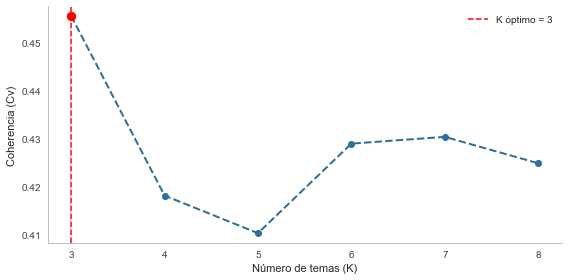

K sugerido por coherencia: 3


In [91]:
k_optimo = K_list[np.argmax(coherencias)]
cv_optima = coherencias[np.argmax(coherencias)]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    K_list,
    coherencias,
    linestyle="--",
    marker="o",
    color="#2e6f95",
    linewidth=2,
    markersize=6
)

ax.axvline(
    k_optimo,
    linestyle="--",
    color="red",
    linewidth=1.5,
    label=f"K óptimo = {k_optimo}"
)

ax.scatter(k_optimo, cv_optima, s=70, color="red", zorder=5)

ax.set_xlabel("Número de temas (K)", fontsize=11)
ax.set_ylabel("Coherencia (Cv)", fontsize=11)
ax.set_xticks(K_list)
ax.set_ylim(min(coherencias) - 0.002, max(coherencias) + 0.002)

# Quitar recuadro feo y dejar solo lo esencial
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#B0B0B0")
ax.spines["bottom"].set_color("#B0B0B0")
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(axis='both', labelsize=10, colors="#444444")
ax.grid(False)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

print("K sugerido por coherencia:", k_optimo)

### ¿Qué es LDA y para qué sirve?

**LDA (Latent Dirichlet Allocation)** es un modelo de **modelado temático**: asume que cada comentario es una mezcla de unos pocos "temas" y que cada tema es una mezcla de palabras. El algoritmo descubre qué temas hay y qué palabras los definen **sin que nosotros le digamos los temas**.

- **Entrada:** muchos textos (comentarios) tokenizados (palabras).
- **Salida:** para cada tema, las palabras más probables (ej. Tema 2: agujas, miedo, fobia → interpretamos "miedo a las agujas"); para cada comentario, la proporción de cada tema.
- **Uso en el TFG:** identificar temas recurrentes (barreras, motivaciones, dudas) y luego clasificarlos en psicológicos, cognitivos o contextuales según las palabras que los definen.

Para que los temas sean interpretables, es importante **limpiar bien el texto**: quitar URLs, stopwords en español e inglés, y palabras sin valor temático. Abajo hacemos esa limpieza mejorada.

In [12]:
# Modelo LDA final con K elegido
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=3, random_state=42, passes=20, alpha="auto", per_word_topics=True)

def tema_dominante(bow):
    if not bow:
        return -1, 0.0
    t = lda.get_document_topics(bow)
    if not t:
        return -1, 0.0
    mejor = max(t, key=lambda x: x[1])
    return mejor[0], mejor[1]

df["tema_id"], df["tema_prob"] = zip(*[tema_dominante(corpus[i]) for i in range(len(corpus))])
df["tema_id"] = df["tema_id"].astype(int)

In [21]:
# Palabras más representativas por tema (para etiquetar y clasificar barreras)
n_topics = 3

for k in range(n_topics):
    terms = lda.show_topic(k, topn=10)
    palabras = ", ".join([w for w, _ in terms])
    print(f"Tema {k}: {palabras}")

Tema 0: trabajo, primero, empresa, hora, ansiedad, buen, único, información, seguridad, dio
Tema 1: vida, hospital, mes, tiempo, hermoso, cruz_roja, mejor, fobia_aguja, bolsa, grupo
Tema 2: miedo_aguja, vez, aguja, miedo, problema, buen, importante, peso, experiencia, enfermedad


In [101]:
from pathlib import Path
import pyLDAvis._prepare as prep

ruta = Path(prep.__file__)
texto = ruta.read_text(encoding="utf-8")

texto = texto.replace("drop('saliency', 1)", "drop('saliency', axis=1)")
texto = texto.replace('drop("saliency", 1)', 'drop("saliency", axis=1)')

ruta.write_text(texto, encoding="utf-8")

print("Parche aplicado en:", ruta)

Parche aplicado en: c:\Users\Usuario\anaconda3\lib\site-packages\pyLDAvis\_prepare.py


In [18]:
## Distancia intertópica
import os
import webbrowser
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()

vis = gensimvis.prepare(
    lda,
    corpus,
    dictionary,
    sort_topics=False,
    mds="mmds"
)

ruta_html = os.path.abspath("distancia_intertopica_k3.html")
pyLDAvis.save_html(vis, ruta_html)

webbrowser.open("file://" + ruta_html)

print("HTML guardado en:", ruta_html)

c:\Users\Usuario\anaconda3\lib\site-packages\sklearn\manifold\_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
HTML guardado en: c:\Users\Usuario\OneDrive - Universidad Pontificia Comillas\SEXTO\TFG\distancia_intertopica_k3.html


## 4. Análisis de sentimiento con BERT (español)

In [19]:
from transformers import pipeline

# Modelo en español para sentimiento (3 clases: positivo, negativo, neutro)
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="pysentimiento/robertuito-sentiment-analysis",
    tokenizer="pysentimiento/robertuito-sentiment-analysis",
    max_length=128,
    truncation=True
)

def predecir_sentimiento(textos, batch_size=32):
    resultados = []
    for i in range(0, len(textos), batch_size):
        lote = textos[i:i+batch_size]
        lote_clean = [str(t)[:500] for t in lote]
        out = sentiment_pipe(lote_clean)
        resultados.extend(out)
    return resultados

textos = df["texto_analisis"].tolist()
print("Clasificando sentimiento (puede tardar varios minutos)...")
sentiments = predecir_sentimiento(textos)
df["sentimiento_etiqueta"] = [s["label"].upper() for s in sentiments]
df["sentimiento_score"] = [s["score"] for s in sentiments]
print(df["sentimiento_etiqueta"].value_counts())

c:\Users\Usuario\anaconda3\lib\site-packages\sympy\external\importtools.py:158: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(modversion) < LooseVersion(min_module_version):
c:\Users\Usuario\anaconda3\lib\site-packages\sympy\external\importtools.py:158: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(modversion) < LooseVersion(min_module_version):
c:\Users\Usuario\anaconda3\lib\site-packages\sympy\core\cache.py:52: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if V(fastcache.__version__) < '0.4.0':
c:\Users\Usuario\anaconda3\lib\site-packages\setuptools\_distutils\version.py:337: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)
Clasificando sentimiento (puede tardar varios minutos)...
sentimiento_etiqueta
NEU    693
NEG    628
POS    506
N

### 4.1 Wordcloud y TF-IDF (unigramas, bigramas, trigramas)

A continuación: nube de palabras y barras de términos con mayor TF-IDF (unigramas, bigramas, trigramas) sobre el corpus de comentarios.

In [64]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import nltk

try:
    from nltk.corpus import stopwords
except:
    nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords

# Stopwords base
STOP_TFIDF = set(stopwords.words("spanish"))

# Stopwords personalizadas para este análisis
STOP_TFIDF |= {
    "jajaja", "jaja", "http", "https", "the", "and", "for", "that", "this",
    "españa", "madrid",

    # términos demasiado generales en tu corpus
    "donar", "donación", "donaciones", "sangre",
    "si", "sí", "bien", "hacer", "hacerlo", "gente",
    "día", "dias", "días", "vez", "veces", "años", "año",
    "puede", "puedo", "puedes", "quiero", "caso", "alguien",
    "ahora", "mucha", "muchas", "mucho", "muchos",
    "gracias", "comentario", "comentarios", "saludo", "saludos",
    "ser", "así", "solo", "tan", "creo", "tipo", "forma",
    "luego", "persona", "personas", "cosas", "algo", "nada"
}

PATRON_URL = re.compile(r"https?://\S+|www\.\S+|\S+\.com\S*|t\.co/\S+", re.IGNORECASE)

def limpiar_texto_ngramas(texto):
    if pd.isna(texto) or not isinstance(texto, str):
        return ""
    t = texto.lower().strip()

    # eliminar urls
    t = PATRON_URL.sub(" ", t)

    # eliminar menciones y hashtags
    t = re.sub(r"[@#]\w+", " ", t)

    # dejar solo letras y espacios
    t = re.sub(r"[^a-záéíóúñü\s]", " ", t)

    # espacios duplicados
    t = re.sub(r"\s+", " ", t).strip()

    # tokenizar y filtrar
    tokens = [
        w for w in t.split()
        if len(w) > 2 and w not in STOP_TFIDF and w.isalpha()
    ]

    return " ".join(tokens)

df["texto_ngramas"] = df["texto_analisis"].fillna("").astype(str).map(limpiar_texto_ngramas)

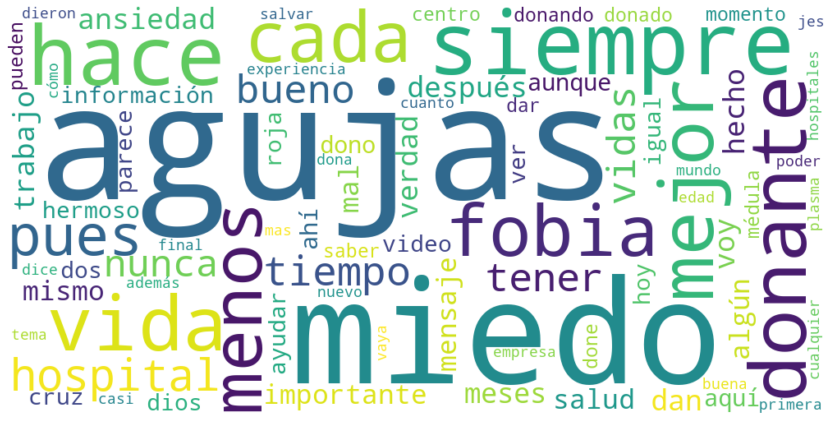

In [86]:
from wordcloud import WordCloud

# Frecuencias de tokens limpios
tokens_wc = " ".join(df["texto_ngramas"]).split()
freq_wc = Counter(tokens_wc)

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=80
).generate_from_frequencies(freq_wc)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
# ax.set_title("Palabras más frecuentes en los comentarios")
plt.tight_layout()
plt.show()

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer

textos_tfidf = df["texto_ngramas"].fillna("").astype(str).tolist()

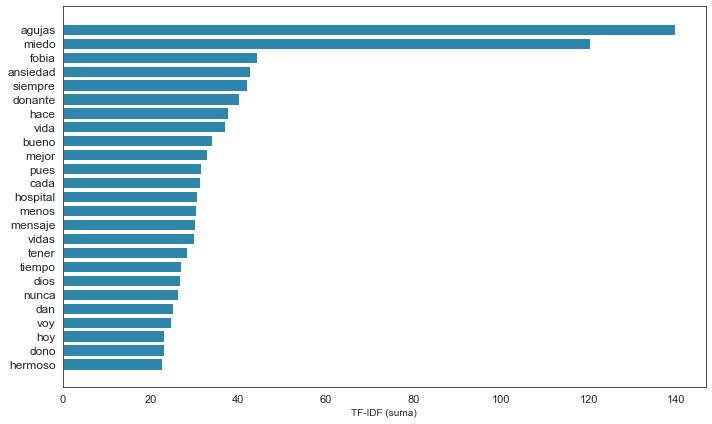

In [79]:
vec1 = TfidfVectorizer(
    max_features=200,
    ngram_range=(1, 1),
    min_df=3,
    max_df=0.8
)

X1 = vec1.fit_transform(textos_tfidf)
idf1 = np.asarray(X1.sum(axis=0)).ravel()
idx1 = np.argsort(-idf1)[:25]

fig, ax = plt.subplots(figsize=(10, 6))
fn1 = vec1.get_feature_names_out()
ax.barh([fn1[i] for i in idx1[::-1]], idf1[idx1[::-1]], color="#2e86ab")
ax.set_xlabel("TF-IDF (suma)")
## ax.set_title("Unigramas con mayor TF-IDF")
ax.tick_params(axis='y', labelsize=12)   # <- tamaño de las palabras
ax.tick_params(axis='x', labelsize=11)
ax.grid(False)
plt.tight_layout()
plt.show()

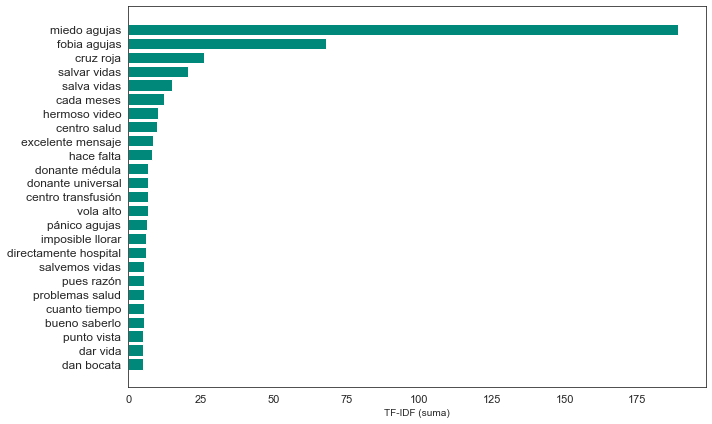

In [81]:
vec2 = TfidfVectorizer(
    max_features=200,
    ngram_range=(2, 2),
    min_df=2,
    max_df=0.8
)

X2 = vec2.fit_transform(textos_tfidf)
idf2 = np.asarray(X2.sum(axis=0)).ravel()
idx2 = np.argsort(-idf2)[:25]

fig, ax = plt.subplots(figsize=(10, 6))
fn2 = vec2.get_feature_names_out()
ax.barh([fn2[i] for i in idx2[::-1]], idf2[idx2[::-1]], color="#00897b")
ax.set_xlabel("TF-IDF (suma)")
# ax.set_title("Bigramas con mayor TF-IDF")
ax.tick_params(axis='y', labelsize=12)   # <- tamaño de las palabras
ax.tick_params(axis='x', labelsize=11)
ax.grid(False)
plt.tight_layout()
plt.show()

In [70]:
STOP_TRIGRAMAS = list(STOP_TFIDF | {"gobierno", "tamaulipas", "impulsa", "campañas"})

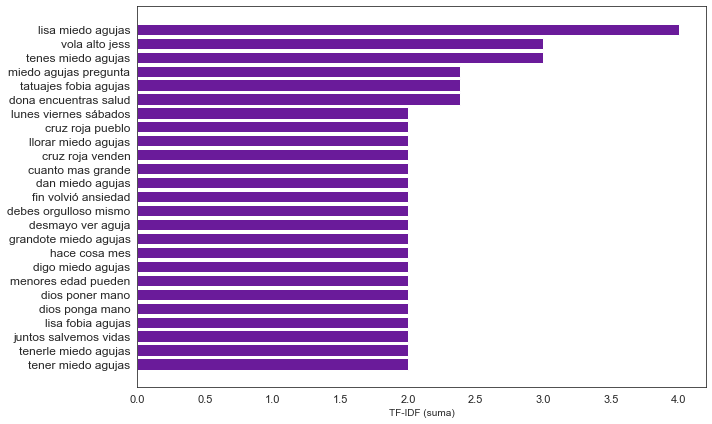

In [82]:
vec3 = TfidfVectorizer(
    max_features=200,
    stop_words=STOP_TRIGRAMAS,
    ngram_range=(3, 3)
)

X3 = vec3.fit_transform(textos_tfidf)
idf3 = np.asarray(X3.sum(axis=0)).ravel()
idx3 = np.argsort(-idf3)[:25]

fig, ax = plt.subplots(figsize=(10, 6))
fn3 = vec3.get_feature_names_out() if hasattr(vec3, 'get_feature_names_out') else vec3.get_feature_names()
nombres3 = [" ".join(v.split(" ")) for v in fn3[idx3[::-1]]]
ax.barh(nombres3, idf3[idx3[::-1]], color="#6a1b9a")
ax.set_xlabel("TF-IDF (suma)")
## ax.set_title("Trigramas con mayor TF-IDF")
ax.tick_params(axis='y', labelsize=12)   # <- tamaño de las palabras
ax.tick_params(axis='x', labelsize=11)
ax.grid(False)
plt.tight_layout()
plt.show()

## 5. Clasificación de temas en tipos de barrera

Mapeo manual de cada tema LDA a: **Psicológica**, **Cognitiva** o **Contextual** (según palabras clave del tema). Debes revisar y ajustar según los temas que hayas obtenido.

In [22]:
# Mapeo tema_id -> tipo de barrera (ajustar según los temas que salgan en tu ejecución)
# Ejemplo: 0=contextual, 1=psicológica, 2=cognitiva, etc.
# Mapeo según tus temas LDA (Tema 0: puedo/salud... Tema 2: agujas/miedo/fobia... etc.)
MAPEO_BARRERAS = {
    0: "Barreras prácticas y organizativas",
    1: "Dimensión institucional y asistencial a la donación",
    2: "Barreras emocionales y médicas"
}

tipo_barrera = {i: MAPEO_BARRERAS.get(i, "Contextual") for i in range(n_topics)}
df["tipo_barrera"] = df["tema_id"].map(tipo_barrera)

## 6. Visualizaciones: por RRSS y global

In [44]:
# Paleta profesional
COLORES_RRSS = {"instagram": "#E1306C", "tiktok": "#00F2EA", "x": "#1DA1F2", "reddit": "#FF4500"}
COLORES_SENT = {"POS": "#2ecc71", "NEG": "#e74c3c", "NEU": "#95a5a6"}
COLORES_BARRERA = {"Barreras prácticas y organizativas": "#9b59b6", "Dimensión institucional y asistencial a la donación": "#3498db", "Barreras emocionales y médicas": "#e67e22"}

### Tabla: Palabras clave, bigramas y trigramas por tópico (estilo TFG)

Categoría = tipo de barrera; palabras clave = unigramas LDA; bigramas/trigramas = más frecuentes en los documentos de ese tema.

In [25]:
# Tabla: Tópico, Categoría, Palabras clave, Bigramas más relevantes, Trigramas más relevantes
from collections import Counter
filas_tabla = []
for k in range(n_topics):
    mask = df["tema_id"] == k
    docs_k = df.loc[mask, "tokens"].dropna()
    # Palabras clave (unigramas) desde LDA
    palabras_lda = ", ".join([w for w, _ in lda.show_topic(k, topn=8)])
    # Bigramas en docs de este tema
    bigrams = []
    for toks in docs_k:
        if isinstance(toks, list) and len(toks) >= 2:
            bigrams.extend([" ".join(toks[i:i+2]) for i in range(len(toks)-1)])
    top_bigrams = ", ".join([b for b, _ in Counter(bigrams).most_common(6)]) if bigrams else ""
    # Trigramas
    trigrams = []
    for toks in docs_k:
        if isinstance(toks, list) and len(toks) >= 3:
            trigrams.extend([" ".join(toks[i:i+3]) for i in range(len(toks)-2)])
    top_trigrams = ", ".join([t for t, _ in Counter(trigrams).most_common(5)]) if trigrams else ""
    filas_tabla.append({
        "Tópico": k + 1,
        "Categoría": tipo_barrera.get(k, "Otro"),
        "Palabra clave": palabras_lda,
        "Bigramas más relevantes": top_bigrams,
    })
tabla_topicos = pd.DataFrame(filas_tabla)
display(tabla_topicos)
(BASE / "resultados_lda_bert").mkdir(exist_ok=True)
tabla_topicos.to_csv(BASE / "resultados_lda_bert" / "tabla_palabras_bigramas_trigramas_por_topico.csv", index=False, encoding="utf-8-sig")

,Tópico,Categoría,Palabra clave,Bigramas más relevantes
0,1,Barreras prácticas y organizativas,"trabajo, primero, empresa, hora, ansiedad, bue...","lista negro, primero trabajo, primero vez, men..."
1,2,Dimensión institucional y asistencial a la don...,"vida, hospital, mes, tiempo, hermoso, cruz_roj...","cruz roja, fobia aguja, salva vida, centro sal..."
2,3,Barreras emocionales y médicas,"miedo_aguja, vez, aguja, miedo, problema, buen...","miedo aguja, fobia aguja, primero vez, pánico ..."


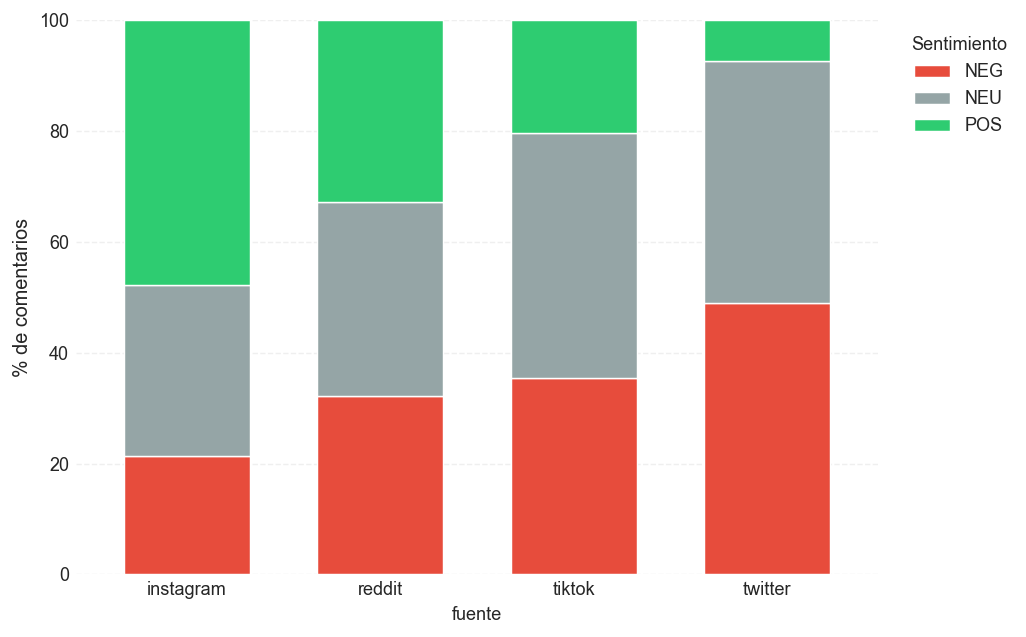

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

ct = pd.crosstab(df["fuente"], df["sentimiento_etiqueta"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Orden correcto de tus etiquetas de sentimiento
orden_sent = ["NEG", "NEU", "POS"]
ct_pct = ct_pct[[c for c in orden_sent if c in ct_pct.columns]].astype(float)

sentimientos = list(ct_pct.columns)
fuentes = list(ct_pct.index)

# Paleta por fuente (mismos colores que ya usaste previamente)
paleta_fuentes = COLORES_RRSS.copy()
paleta_fuentes.setdefault("twitter", paleta_fuentes.get("x", "#1DA1F2"))
paleta_fuentes.setdefault("Twitter", paleta_fuentes.get("x", "#1DA1F2"))
paleta_fuentes.setdefault("X", paleta_fuentes.get("x", "#1DA1F2"))

fig, ax = plt.subplots(figsize=(9, 5), dpi=130)
x = list(range(len(sentimientos)))
n_fuentes = max(1, len(fuentes))
ancho = 0.8 / n_fuentes

for i, fuente in enumerate(fuentes):
    color = paleta_fuentes.get(fuente, "gray")
    valores = ct_pct.loc[fuente, sentimientos].values
    ax.bar(
        [xi + i * ancho for xi in x],
        valores,
        width=ancho,
        label=fuente,
        color=color,
        edgecolor="white",
        linewidth=0.8,
        alpha=0.9,
    )

ax.set_xticks([xi + ancho * (n_fuentes - 1) / 2 for xi in x])
ax.set_xticklabels(sentimientos, rotation=0)
ax.set_ylabel("% de comentarios", fontsize=11)
ax.set_ylim(0, 100)

ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="x", rotation=30, length=0)
ax.tick_params(axis="y", length=0)

ax.legend(
    title="Fuente",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

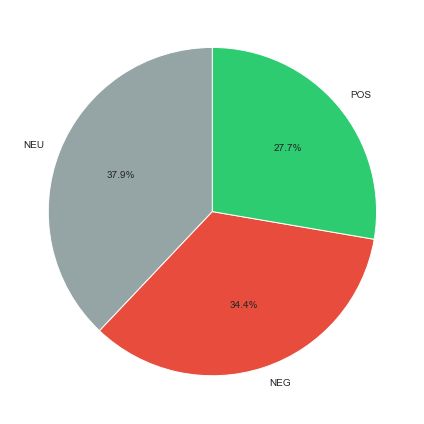

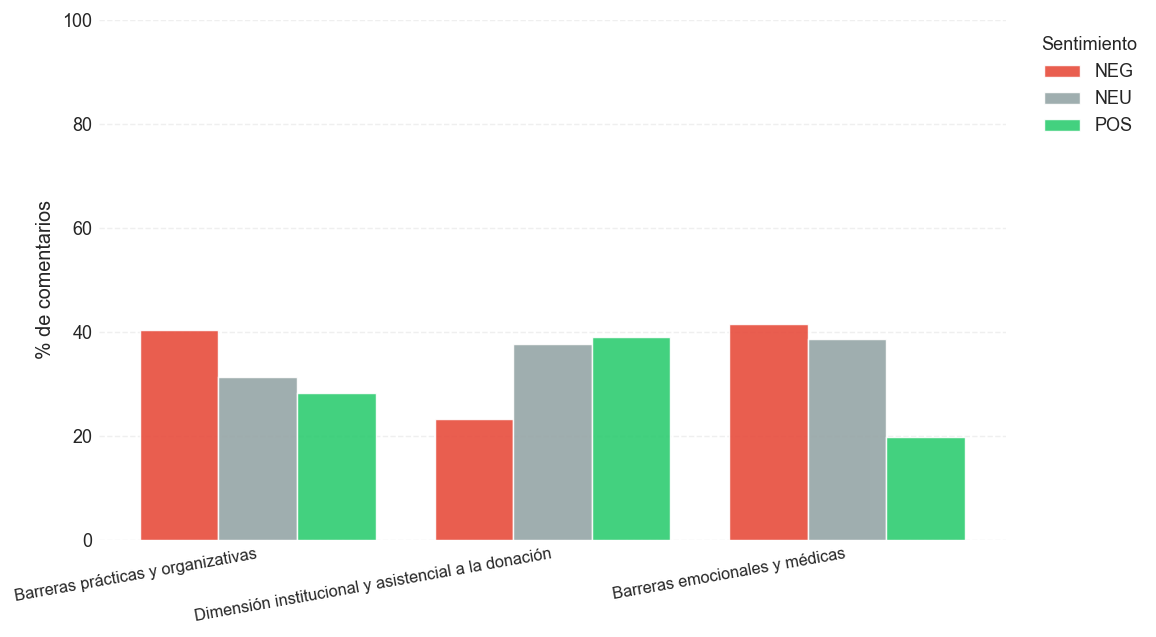

In [77]:
# 6.2 Sentimiento global (pie)
sent_global = df["sentimiento_etiqueta"].value_counts()
colors_pie = [COLORES_SENT.get(s, "gray") for s in sent_global.index]
plt.figure(figsize=(6, 6))
plt.pie(sent_global, labels=sent_global.index, autopct="%1.1f%%", colors=colors_pie, startangle=90)
# plt.title("Distribución global de sentimiento")
plt.tight_layout()
plt.show()

# 6.2.1 Sentimiento por tópico (barras agrupadas)
orden_sent = ["NEG", "NEU", "POS"]
temas = [0, 1, 2]
ct_tema_sent = pd.crosstab(df["tema_id"], df["sentimiento_etiqueta"])
ct_tema_sent = ct_tema_sent.reindex(index=temas, columns=orden_sent, fill_value=0)
ct_tema_sent_pct = ct_tema_sent.div(ct_tema_sent.sum(axis=1), axis=0).fillna(0) * 100
sentimientos = list(ct_tema_sent_pct.columns)

colores_temas = ["#1f77b4", "#ff7f0e", "#2ca02c"]
mapeo_barreras = globals().get("MAPEO_BARRERAS", {})

labels_temas = [mapeo_barreras.get(tema, f"Tema {tema}") for tema in temas]
colores_sent = [COLORES_SENT.get(s, "gray") for s in sentimientos]

fig, ax = plt.subplots(figsize=(9, 5), dpi=130)
x = list(range(len(labels_temas)))
ancho = 0.8 / len(sentimientos)

for i, sentimiento in enumerate(sentimientos):
    valores = ct_tema_sent_pct[sentimiento].values
    ax.bar(
        [xi + i * ancho for xi in x],
        valores,
        width=ancho,
        color=colores_sent[i],
        label=sentimiento,
        edgecolor="white",
        linewidth=0.8,
        alpha=0.9,
    )

ax.set_xticks([xi + ancho * (len(sentimientos) - 1) / 2 for xi in x])
ax.set_xticklabels(labels_temas, rotation=10, ha="right", fontsize=9)
ax.set_ylabel("% de comentarios", fontsize=11)
ax.set_ylim(0, 100)

ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="x", rotation=10, length=0)
ax.tick_params(axis="y", length=0)

ax.legend(
    title="Sentimiento",
    labels=sentimientos,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

#### 6.2.2 Evolución del sentimiento en el tiempo

Se construye una **puntuación compuesta** a partir de la etiqueta BERT (NEG/NEU/POS) y su score de confianza: NEG → −score, NEU → 0, POS → +score. Se promedia por mes y se representa la evolución temporal (estilo Figura 4.12).

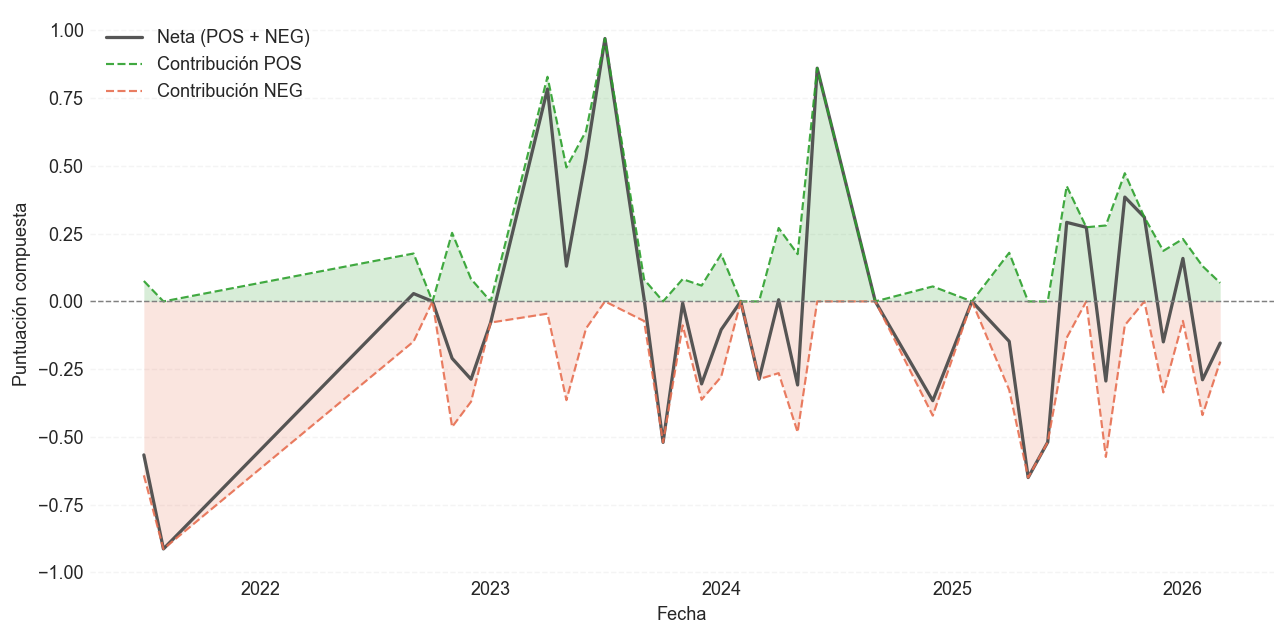

In [81]:
# Evolución del sentimiento en el tiempo (puntuación compuesta BERT)
import numpy as np

df_evol = df.copy()
df_evol["fecha_dt"] = pd.to_datetime(df_evol["fecha"], errors="coerce")
df_evol = df_evol.dropna(subset=["fecha_dt"])
if "sentimiento_score" not in df_evol.columns:
    df_evol["sentimiento_score"] = 0.5
s = df_evol["sentimiento_score"].astype(float)
et = df_evol["sentimiento_etiqueta"]
df_evol["puntuacion_compuesta"] = np.where(et == "NEG", -s, np.where(et == "POS", s, 0.0))
por_fecha = df_evol.groupby(df_evol["fecha_dt"].dt.to_period("M"))["puntuacion_compuesta"].mean()
por_fecha.index = por_fecha.index.to_timestamp()
por_fecha = por_fecha.sort_index()

# Contribuciones separadas para visualizar cuándo domina lo positivo/negativo
pos_mean = (
    df_evol.assign(pos_contrib=np.where(et == "POS", s, 0.0))
    .groupby(df_evol["fecha_dt"].dt.to_period("M"))["pos_contrib"]
    .mean()
)
neg_mean = (
    df_evol.assign(neg_contrib=np.where(et == "NEG", -s, 0.0))
    .groupby(df_evol["fecha_dt"].dt.to_period("M"))["neg_contrib"]
    .mean()
)

pos_mean.index = pos_mean.index.to_timestamp()
neg_mean.index = neg_mean.index.to_timestamp()

pos_mean = pos_mean.sort_index()
neg_mean = neg_mean.sort_index()

all_months = pos_mean.index.union(neg_mean.index).sort_values()
pos_mean = pos_mean.reindex(all_months).fillna(0.0)
neg_mean = neg_mean.reindex(all_months).fillna(0.0)
net = pos_mean + neg_mean

fig, ax = plt.subplots(figsize=(10, 5), dpi=130)

x = all_months.to_numpy()
y_net = net.to_numpy(dtype=float)
y_pos = pos_mean.to_numpy(dtype=float)
y_neg = neg_mean.to_numpy(dtype=float)

POS_COLOR = "#2ca02c"   # verde
NEG_COLOR = "#e76f51"   # naranja/rojo
NET_COLOR = "#4d4d4d"   # gris neutro

# Sombreado para remarcar la polaridad
ax.fill_between(x, 0, y_pos, color=POS_COLOR, alpha=0.18, linewidth=0)
ax.fill_between(x, y_neg, 0, color=NEG_COLOR, alpha=0.18, linewidth=0)

# Líneas (neto + contribuciones)
ax.plot(x, y_net, color=NET_COLOR, linewidth=1.8, alpha=0.95, label="Neta (POS + NEG)")
ax.plot(x, y_pos, color=POS_COLOR, linewidth=1.2, linestyle="--", alpha=0.9, label="Contribución POS")
ax.plot(x, y_neg, color=NEG_COLOR, linewidth=1.2, linestyle="--", alpha=0.9, label="Contribución NEG")

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

ax.set_ylabel("Puntuación compuesta")
ax.set_xlabel("Fecha")

# Estilo limpio: sin ejes visibles (rejilla suave en Y)
ax.grid(True, axis="y", linestyle="--", alpha=0.2)
ax.tick_params(axis="both", which="both", length=0)
ax.set_axisbelow(True)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

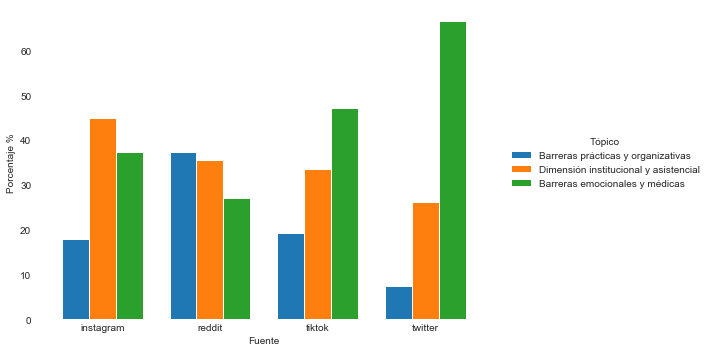

In [71]:
# 6.3 Temas por fuente (barras agrupadas) — solo temas 0, 1, 2
n_topics_lda = 3  # mismo que en tu LDA (num_topics=3)
ct_temas = pd.crosstab(df["fuente"], df["tema_id"])
# Asegurar que solo hay columnas 0, 1, 2 y en ese orden
for k in range(n_topics_lda):
    if k not in ct_temas.columns:
        ct_temas[k] = 0
ct_temas = ct_temas[[0, 1, 2]]
ct_temas_pct = ct_temas.div(ct_temas.sum(axis=1), axis=0) * 100
# Tres colores fijos para Tema 0, 1, 2
colores_temas = ["#1f77b4", "#ff7f0e", "#2ca02c"]
ct_temas_pct.plot(kind="bar", figsize=(10, 5), width=0.75, color=colores_temas)
# plt.title("Distribución de temas LDA por red social (%)")
plt.ylabel("Porcentaje %")
plt.xlabel("Fuente")
ax = plt.gca()
# Ocultar líneas de ejes y ticks para que el gráfico se vea limpio
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
# Quitar marcas/ticks (solo mantenemos los labels del eje X)
ax.tick_params(axis="both", which="both", length=0)
ax.grid(False)
ax.legend(title="Tópico", labels=["Barreras prácticas y organizativas", "Dimensión institucional y asistencial", "Barreras emocionales y médicas"], loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

c:\Users\Usuario\anaconda3\lib\site-packages\seaborn\matrix.py:68: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros(data.shape, np.bool)
c:\Users\Usuario\anaconda3\lib\site-packages\seaborn\matrix.py:78: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype=np.bool)


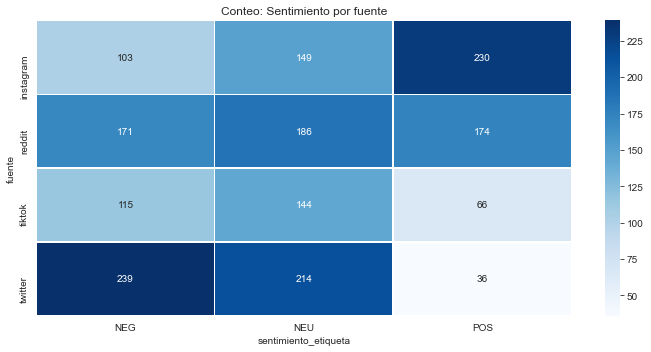

In [82]:
# 6.5 Heatmap: Sentimiento vs Fuente (conteos)
heat = pd.crosstab(df["fuente"], df["sentimiento_etiqueta"])
sns.heatmap(heat, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Conteo: Sentimiento por fuente")
plt.tight_layout()
plt.show()

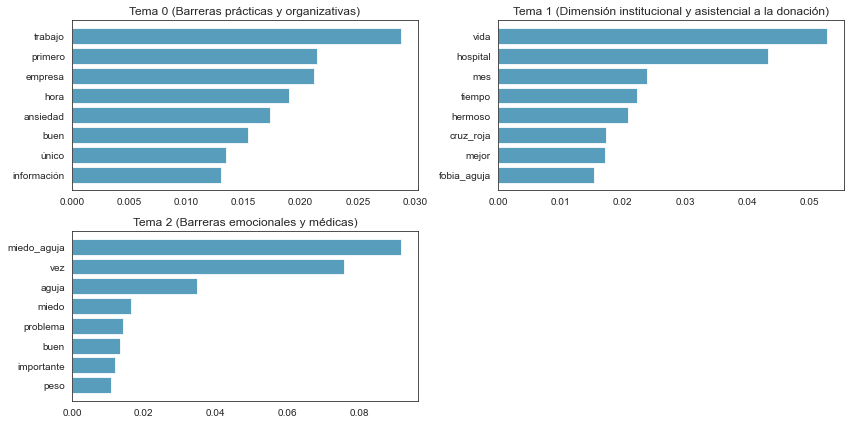

In [80]:
# 6.6 Top palabras por tema (barras horizontales)
n_rows = max(1, (n_topics + 1) // 2)
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 3 * n_rows))
axes = np.atleast_1d(axes).flatten()
for k in range(n_topics):
    terms = lda.show_topic(k, topn=8)
    words = [w for w, _ in terms][::-1]
    probs = [p for _, p in terms][::-1]
    axes[k].barh(words, probs, color="#2e86ab", alpha=0.8)
    axes[k].set_title(f"Tema {k} ({tipo_barrera.get(k, 'Otro')})")
for j in range(n_topics, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Exportar resultados para el informe

In [ ]:
out_dir = BASE / "resultados_lda_bert"
out_dir.mkdir(exist_ok=True)

df.to_csv(out_dir / "datos_con_temas_y_sentimiento.csv", index=False, encoding="utf-8-sig")
print("Guardado: datos_con_temas_y_sentimiento.csv")

resumen_sent = df.groupby("fuente")["sentimiento_etiqueta"].value_counts().unstack(fill_value=0)
resumen_sent.to_csv(out_dir / "resumen_sentimiento_por_fuente.csv", encoding="utf-8-sig")
print("Guardado: resumen_sentimiento_por_fuente.csv")

resumen_barrera = df.groupby("fuente")["tipo_barrera"].value_counts().unstack(fill_value=0)
resumen_barrera.to_csv(out_dir / "resumen_barreras_por_fuente.csv", encoding="utf-8-sig")
print("Guardado: resumen_barreras_por_fuente.csv")

In [ ]:
# Guardar figuras (descomenta y ejecuta después de generar los gráficos)
# for i, fig in enumerate(plt.get_fignums()):
#     plt.figure(fig).savefig(out_dir / f"figura_{i}.png", dpi=150, bbox_inches="tight")